# GRASP sensor selection for the ANN detector

This notebook demonstrates GRASP with path relinking and applies it to select the chlorine-sensor subset for the **weak-contamination dataset only**. The production detector keeps the chlorine regressor fixed at `(128, 64, 32)` and the event classifier fixed at `(32,)`.

GRASP may select at most one third of the available chlorine sensors. Candidate subsets are ranked using validation balanced accuracy; the held-out test scenarios are evaluated only after selection.


In [1]:
from pathlib import Path
import sys

# Make the project importable whether Jupyter starts in the repository root or src/notebooks.
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parents[1]
sys.path.insert(0, str(project_root))

from src.event_detection_pipeline.grasp import (
    GraspConfig,
    grasp_architecture_search,
    parameter_count,
)

## 1. Fast, transparent example

Training many ANNs is slow, so this first evaluator is a deterministic stand-in for validation balanced accuracy. It lets us inspect construction, local search, the elite pool, and path relinking immediately.

In [2]:
evaluated = []

def transparent_evaluator(hidden_sizes):
    # Saturating score with a small reward for distributing neurons across both layers.
    h1, h2 = hidden_sizes
    score = min(1.0, (h1 + 1.5 * h2) / 80.0)
    score += min(h1, h2) / 10_000.0
    evaluated.append((hidden_sizes, score))
    return score

config = GraspConfig(
    iterations=8,
    max_evaluations=60,   # runtime limit, not a neuron limit
    elite_size=6,
    relink_solutions=2,
    min_hidden_size=4,
    alpha=0.3,            # greediness/randomness balance for the RCL
    random_seed=42,
)

result = grasp_architecture_search(
    transparent_evaluator,
    input_dim=20,
    baseline_hidden_sizes=(128, 64),
    config=config,
)
result

GraspResult(hidden_sizes=(64, 64), metric=1.0064, baseline_metric=1.0064, parameter_count=5569, evaluations=27, elite=(ArchitectureScore(hidden_sizes=(64, 64), metric=1.0064, parameter_count=5569, feasible=True), ArchitectureScore(hidden_sizes=(128, 64), metric=1.0064, parameter_count=11009, feasible=True)))

In [3]:
print(f"Baseline metric:       {result.baseline_metric:.4f}")
print(f"Selected metric:       {result.metric:.4f}")
print(f"Selected architecture: {result.hidden_sizes}")
print(f"Selected parameters:   {result.parameter_count:,}")
print(f"Baseline parameters:   {parameter_count(20, (128, 64)):,}")
print(f"Unique evaluations:    {result.evaluations}")

print("\nElite pool:")
for item in result.elite:
    print(item)

Baseline metric:       1.0064
Selected metric:       1.0064
Selected architecture: (64, 64)
Selected parameters:   5,569
Baseline parameters:   11,009
Unique evaluations:    27

Elite pool:
ArchitectureScore(hidden_sizes=(64, 64), metric=1.0064, parameter_count=5569, feasible=True)
ArchitectureScore(hidden_sizes=(128, 64), metric=1.0064, parameter_count=11009, feasible=True)


## 2. Correspondence with Algorithm 6

- `construct()` starts at a small ANN and doubles one selected layer. Candidate moves form a restricted candidate list (RCL), from which one is chosen randomly.
- Feasibility means `metric >= baseline_metric - metric_tolerance`; construction therefore stops growing when it matches the ANN without GRASP.
- `local_search()` reduces layer widths while preserving feasibility.
- `path_relink()` moves one layer at a time from the new solution toward a randomly selected elite solution.
- `update_elite()` retains the smallest feasible architectures, breaking ties by better metric.
- The returned solution is the feasible elite member with the fewest trainable parameters.

The baseline itself is inserted into the elite pool. Thus the search can never return an architecture that fails the chosen target merely because its evaluation budget expires.

## 3. Real ANN evaluator on synthetic imbalanced event data

This cell uses the repository's `train_event_classifier`. Each architecture is trained with a deterministic seed, its alarm threshold is calibrated on validation data, and balanced accuracy is returned. Replace these arrays with the scaled classifier features assembled in `build_detector` to run the same search on the arsenic scenarios.

In [4]:
import numpy as np
import torch

from src.event_detection_pipeline.model import (
    predict_event_probability,
    select_device,
    train_event_classifier,
)
from src.event_detection_pipeline.pipeline import _calibrate_balanced_accuracy_threshold

rng = np.random.default_rng(42)
X = rng.normal(size=(1200, 12)).astype(np.float32)
signal = 1.8 * X[:, 0] - X[:, 1] + 0.7 * X[:, 2] * X[:, 3]
y = (signal > np.quantile(signal, 0.88)).astype(np.float32)
order = rng.permutation(len(X))
train_index, validation_index = order[:900], order[900:]
X_train, y_train = X[train_index], y[train_index]
X_validation, y_validation = X[validation_index], y[validation_index]
device = select_device()

trained_models = {}

def ann_evaluator(hidden_sizes):
    # Stable per-architecture seed makes cached comparisons reproducible.
    seed = 42 + sum((i + 1) * width for i, width in enumerate(hidden_sizes))
    np.random.seed(seed)
    torch.manual_seed(seed)
    model = train_event_classifier(
        X_train, y_train, X_validation, y_validation, device,
        hidden_sizes=hidden_sizes,
        epochs=30,
        patience=5,
        batch_size=128,
    )
    probability = predict_event_probability(model, X_validation, device)
    threshold = _calibrate_balanced_accuracy_threshold(
        y_validation.astype(bool), probability
    )
    alarms = probability >= threshold
    flags = y_validation.astype(bool)
    sensitivity = alarms[flags].mean()
    specificity = (~alarms[~flags]).mean()
    trained_models[tuple(hidden_sizes)] = model
    return float(0.5 * (sensitivity + specificity))

In [5]:
# This cell trains several networks and can take a few minutes.
ann_result = grasp_architecture_search(
    ann_evaluator,
    input_dim=X_train.shape[1],
    baseline_hidden_sizes=(128, 64),
    config=GraspConfig(
        iterations=4,
        max_evaluations=20,
        elite_size=4,
        relink_solutions=1,
        min_hidden_size=4,
        # A small tolerance is often sensible because ANN training is noisy.
        metric_tolerance=0.005,
        random_seed=42,
    ),
)
ann_result

GraspResult(hidden_sizes=(32, 63), metric=0.9124513618677043, baseline_metric=0.9105510813501041, parameter_count=2559, evaluations=20, elite=(ArchitectureScore(hidden_sizes=(32, 63), metric=0.9124513618677043, parameter_count=2559, feasible=True), ArchitectureScore(hidden_sizes=(128, 64), metric=0.9105510813501041, parameter_count=9985, feasible=True)))

## 4. Production GRASP sensor search: weak versus strong contamination

The same protocol is run independently on weak- and strong-contamination files. The regressor `(128, 64, 32)` and classifier `(32,)` remain fixed; GRASP changes only the chlorine-sensor subset, with a hard cap of one third of the available sensors.

Fitness is validation balanced accuracy. Recall, specificity and false-alarm rate (FAR) are also recorded for every evaluated subset so we can test whether fewer sensors systematically increase false positives. The outer test scenarios remain untouched until selection is complete.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.event_detection import (
    SensorGraspConfig,
    aggregate_evaluation_summary,
    build_detector,
    collect_default_data_paths,
    collect_strong_contamination_paths,
    grasp_sensor_subset_search,
    split_train_test,
)
from src.event_detection_pipeline.data import split_file
from src.event_detection_pipeline.evaluation import (
    plot_chlorine_prediction_quality,
    plot_precision_recall_curve,
    plot_roc_curve_event_detection,
)
from src.event_detection_pipeline.model_io import save_detector

REGRESSION_HIDDEN_SIZES = (128, 64, 32)
CLASSIFIER_HIDDEN_SIZES = (32,)
HISTORY = 48
EPOCHS = 60
BATCH_SIZE = 128
LEARNING_RATE = 3e-4
DROPOUT = 0.0
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 8
MAX_VALIDATION_FALSE_ALARM_RATE = 0.2
RANDOM_SEED = 42


In [7]:
def train_fixed_detector(fit_paths, sensor_indices):
    return build_detector(
        fit_paths,
        history=HISTORY,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        hidden_sizes=REGRESSION_HIDDEN_SIZES,
        dropout=DROPOUT,
        weight_decay=WEIGHT_DECAY,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        max_validation_false_alarm_rate=MAX_VALIDATION_FALSE_ALARM_RATE,
        classifier_hidden_sizes=CLASSIFIER_HIDDEN_SIZES,
        chlorine_sensor_indices=sensor_indices,
        grasp_config=None,
        random_seed=RANDOM_SEED,
    )

def run_sensor_experiment(dataset_name, data_paths):
    train_paths, test_paths = split_train_test(data_paths)
    sensor_fit_paths, sensor_validation_paths = split_train_test(train_paths)
    _, sensor_groups = split_file(sensor_fit_paths[0], history=HISTORY)
    sensor_count = len(sensor_groups.chlorine)
    max_sensors = max(1, sensor_count // 3)
    evaluation_records = []

    print(f"\n{dataset_name.upper()} CONTAMINATION")
    print(f"Outer train/test: {len(train_paths)}/{len(test_paths)} files")
    print(f"Search fit/validation: {len(sensor_fit_paths)}/{len(sensor_validation_paths)} files")
    print(f"Sensor budget: at most {max_sensors} of {sensor_count}")

    def evaluate_subset(sensor_indices, label="GRASP candidate"):
        detector = train_fixed_detector(sensor_fit_paths, sensor_indices)
        validation_results = [detector.detect(path) for path in sensor_validation_paths]
        metrics = aggregate_evaluation_summary(validation_results)
        nodes = [sensor_groups.chlorine_nodes[index] for index in sensor_indices]
        record = {
            "dataset": dataset_name,
            "label": label,
            "subset": tuple(sensor_indices),
            "nodes": tuple(nodes),
            "sensor_count": len(sensor_indices),
            **metrics,
        }
        evaluation_records.append(record)
        print(
            f"subset={tuple(sensor_indices)}, nodes={nodes}, "
            f"BA={metrics['balanced_accuracy']:.4f}, "
            f"recall={metrics['recall']:.4f}, "
            f"specificity={metrics['specificity']:.4f}, "
            f"FAR={metrics['false_alarm_rate']:.4f}"
        )
        return metrics["balanced_accuracy"]

    # Reference needed to compare the capped subsets with all available sensors.
    all_sensor_indices = tuple(range(sensor_count))
    evaluate_subset(all_sensor_indices, label="all-sensor validation baseline")

    search_result = grasp_sensor_subset_search(
        evaluate_subset,
        sensor_count=sensor_count,
        max_sensors=max_sensors,
        config=SensorGraspConfig(
            iterations=8,
            max_evaluations=40,
            elite_size=6,
            relink_solutions=2,
            alpha=0.3,
            random_seed=RANDOM_SEED,
        ),
    )
    selected_indices = list(search_result.sensor_indices)
    selected_nodes = [sensor_groups.chlorine_nodes[index] for index in selected_indices]
    assert 1 <= len(selected_indices) <= max_sensors

    # Final selected and all-sensor reference models use the same outer training set.
    selected_detector = train_fixed_detector(train_paths, selected_indices)
    all_sensor_detector = train_fixed_detector(train_paths, all_sensor_indices)
    save_detector(
        selected_detector,
        directory=str(
            project_root / "results" / "ANN"
            / f"grasp_sensor_{dataset_name}_128-64-32_classifier-32"
        ),
    )
    return {
        "name": dataset_name,
        "groups": sensor_groups,
        "max_sensors": max_sensors,
        "search_result": search_result,
        "records": pd.DataFrame(evaluation_records),
        "selected_indices": selected_indices,
        "selected_nodes": selected_nodes,
        "selected_detector": selected_detector,
        "all_sensor_detector": all_sensor_detector,
        "test_paths": test_paths,
    }

weak_experiment = run_sensor_experiment(
    "weak", collect_default_data_paths(project_root / "src" / "data")
)
strong_experiment = run_sensor_experiment(
    "strong", collect_strong_contamination_paths(project_root / "src" / "data")
)
experiments = [weak_experiment, strong_experiment]



WEAK CONTAMINATION
Outer train/test: 16/4 files
Search fit/validation: 13/3 files
Sensor budget: at most 3 of 9
subset=(0, 1, 2, 3, 4, 5, 6, 7, 8), nodes=['10', '11', '12', '13', '21', '22', '23', '31', '32'], BA=0.6913, recall=0.6884, specificity=0.6941, FAR=0.3059
subset=(3,), nodes=['13'], BA=0.6585, recall=0.6683, specificity=0.6487, FAR=0.3513
subset=(0,), nodes=['10'], BA=0.6093, recall=0.6583, specificity=0.5604, FAR=0.4396
subset=(7,), nodes=['31'], BA=0.6038, recall=0.7538, specificity=0.4538, FAR=0.5462
subset=(2,), nodes=['12'], BA=0.5928, recall=0.8141, specificity=0.3715, FAR=0.6285
subset=(4,), nodes=['21'], BA=0.6026, recall=0.8040, specificity=0.4013, FAR=0.5987
subset=(6,), nodes=['23'], BA=0.6497, recall=0.7387, specificity=0.5607, FAR=0.4393
subset=(1,), nodes=['11'], BA=0.6449, recall=0.7387, specificity=0.5510, FAR=0.4490
subset=(5,), nodes=['22'], BA=0.6702, recall=0.6884, specificity=0.6520, FAR=0.3480
subset=(8,), nodes=['32'], BA=0.6180, recall=0.7136, specifi

### Interpreting false positives

Fewer sensors provide less information and may increase FAR, but this is a hypothesis rather than a guaranteed monotonic relationship. Removing noisy or redundant sensors can improve specificity. The tables and plots below report the observed relationship for every subset actually evaluated by GRASP, plus an all-sensor reference.


,dataset,label,subset,nodes,sensor_count,balanced_accuracy,recall,specificity,false_alarm_rate,precision,f1_score,roc_auc,average_precision,chlorine_rmse,chlorine_mae,chlorine_r2
50,strong,GRASP candidate,"(8,)","(32,)",1,0.672254,0.385230,0.959278,0.040722,0.665517,0.487990,0.737837,0.530353,0.050006,0.032016,0.833986
47,strong,GRASP candidate,"(6,)","(23,)",1,0.661765,0.620758,0.702771,0.297229,0.305201,0.409211,0.731586,0.399376,0.062538,0.042765,0.795925
44,strong,GRASP candidate,"(7,)","(31,)",1,0.640184,0.594810,0.685558,0.314442,0.284623,0.385013,0.689518,0.318755,0.048239,0.022047,0.809817
49,strong,GRASP candidate,"(5,)","(22,)",1,0.609504,0.856287,0.362720,0.637280,0.220339,0.350490,0.688852,0.327666,0.054190,0.029886,0.907907
42,strong,GRASP candidate,"(3,)","(13,)",1,0.603050,0.634731,0.571369,0.428631,0.237491,0.345652,0.651658,0.270614,0.051555,0.025131,0.917831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,weak,GRASP candidate,"(0, 2, 8)","(10, 12, 32)",3,0.654707,0.613065,0.696349,0.303651,0.130203,0.214789,0.693355,0.149490,0.038990,0.016976,0.939265
21,weak,GRASP candidate,"(2, 3, 5)","(12, 13, 22)",3,0.635226,0.442211,0.828241,0.171759,0.160291,0.235294,0.725927,0.142506,0.051119,0.024587,0.925430
28,weak,GRASP candidate,"(0, 3, 5)","(10, 13, 22)",3,0.629724,0.457286,0.802161,0.197839,0.146302,0.221681,0.721454,0.131067,0.045148,0.019188,0.930774
36,weak,GRASP candidate,"(0, 2, 7)","(10, 12, 31)",3,0.614680,0.758794,0.470566,0.529434,0.096056,0.170525,0.694342,0.146659,0.038032,0.013072,0.939458


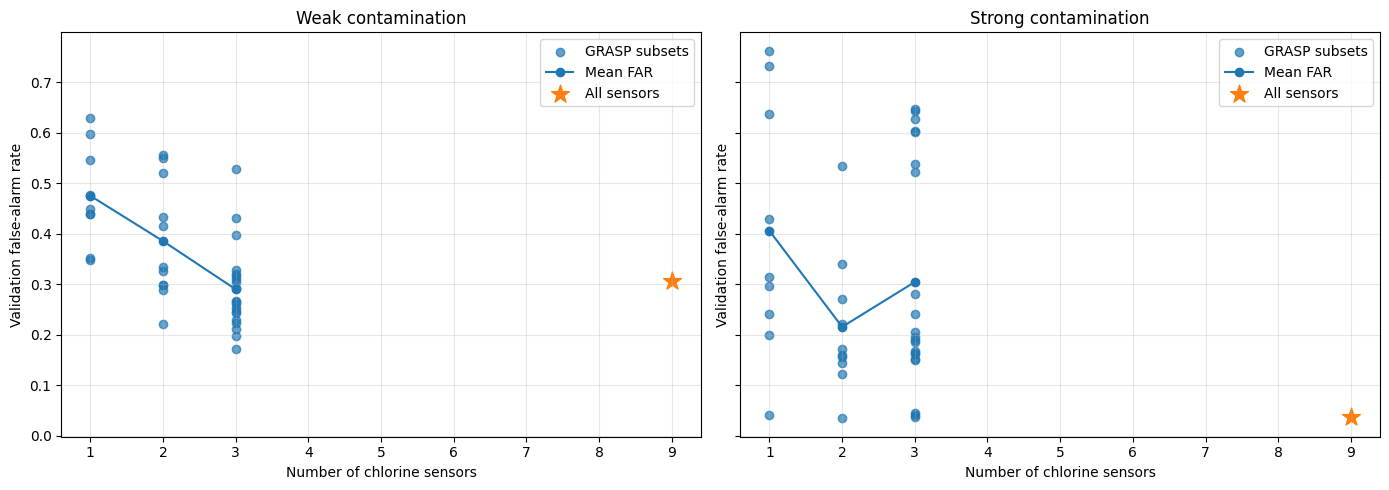


WEAK GRASP result
  selected indices: (1, 2, 4)
  selected nodes: ['11', '12', '21']
  validation BA: 0.7018
  evaluated subsets: 40
  Spearman(sensor count, FAR): -0.6494

STRONG GRASP result
  selected indices: (5, 6, 7)
  selected nodes: ['22', '23', '31']
  validation BA: 0.6848
  evaluated subsets: 40
  Spearman(sensor count, FAR): -0.1308


In [8]:
all_search_records = pd.concat(
    [experiment["records"] for experiment in experiments], ignore_index=True
)
comparison_columns = [
    "dataset", "label", "subset", "nodes", "sensor_count",
    "balanced_accuracy", "recall", "specificity", "false_alarm_rate",
    "precision", "f1_score", "roc_auc", "average_precision",
    "chlorine_rmse", "chlorine_mae", "chlorine_r2",
]
display(all_search_records[comparison_columns].sort_values(
    ["dataset", "sensor_count", "balanced_accuracy"],
    ascending=[True, True, False],
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, experiment in zip(axes, experiments):
    records = experiment["records"]
    candidates = records[records["label"] == "GRASP candidate"]
    axis.scatter(
        candidates["sensor_count"], candidates["false_alarm_rate"],
        alpha=0.7, label="GRASP subsets",
    )
    means = candidates.groupby("sensor_count")["false_alarm_rate"].mean()
    axis.plot(means.index, means.values, "o-", label="Mean FAR")
    baseline = records[records["label"] == "all-sensor validation baseline"].iloc[0]
    axis.scatter(
        [baseline["sensor_count"]], [baseline["false_alarm_rate"]],
        marker="*", s=180, label="All sensors",
    )
    axis.set_title(f"{experiment['name'].title()} contamination")
    axis.set_xlabel("Number of chlorine sensors")
    axis.set_ylabel("Validation false-alarm rate")
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

for experiment in experiments:
    candidates = experiment["records"].query("label == 'GRASP candidate'")
    correlation = candidates["sensor_count"].corr(
        candidates["false_alarm_rate"], method="spearman"
    )
    result = experiment["search_result"]
    print(f"\n{experiment['name'].upper()} GRASP result")
    print(f"  selected indices: {result.sensor_indices}")
    print(f"  selected nodes: {experiment['selected_nodes']}")
    print(f"  validation BA: {result.metric:.4f}")
    print(f"  evaluated subsets: {result.evaluations}")
    print(f"  Spearman(sensor count, FAR): {correlation:.4f}")


## 5. Final held-out comparison

For each contamination strength, the GRASP-selected detector and the all-sensor reference are evaluated on the same untouched outer test scenarios. This is the appropriate comparison for determining whether the reduced sensor set changes false positives or detection performance.


In [9]:
def plot_metrics(result, title_prefix="", chlorine_indices=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    matrix = confusion_matrix(
        result.event_flags.astype(bool),
        result.alarms.astype(bool),
        labels=[False, True],
        normalize="all",
    )
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix, display_labels=["Normal", "Event"]
    )
    display_matrix.plot(ax=axes[0, 0], colorbar=False, values_format=".2f")
    axes[0, 0].set_title(f"{title_prefix}Confusion Matrix")
    plot_roc_curve_event_detection(
        result, title=f"{title_prefix}Event Detection ROC", ax=axes[0, 1]
    )
    plot_chlorine_prediction_quality(
        result,
        chlorine_indices=chlorine_indices,
        title=f"{title_prefix}Chlorine Prediction Quality",
        ax=axes[1, 0],
    )
    plot_precision_recall_curve(
        result, title=f"{title_prefix}Precision-Recall Curve", ax=axes[1, 1]
    )
    plt.tight_layout()
    plt.show()
    return fig, axes

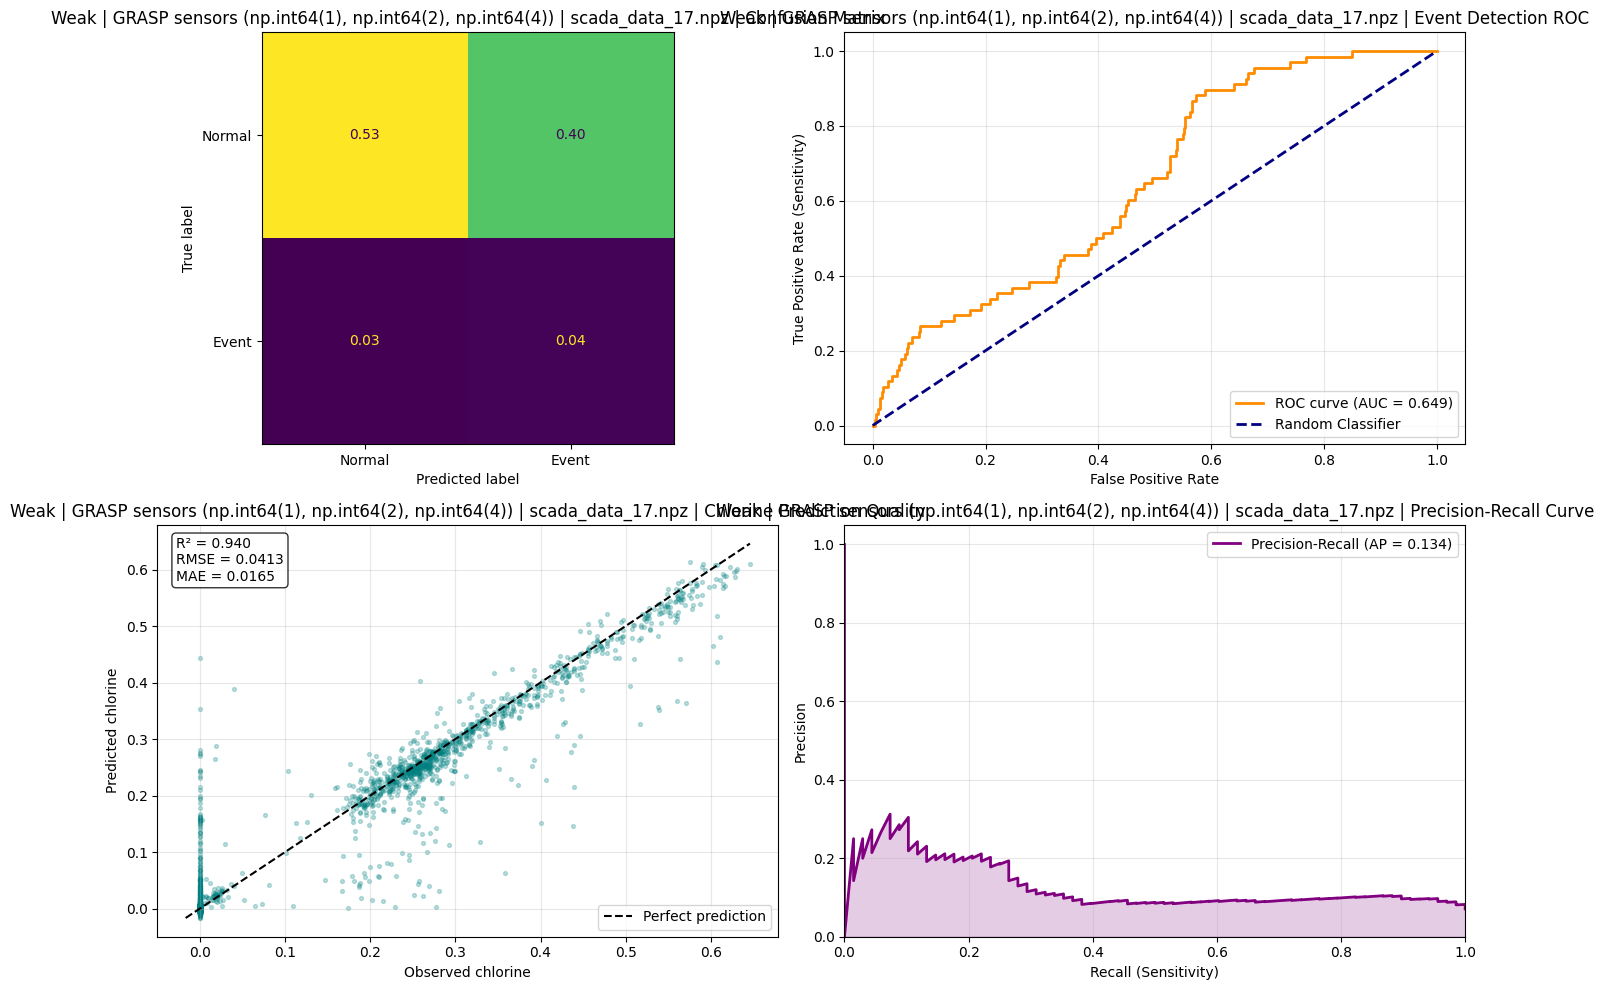

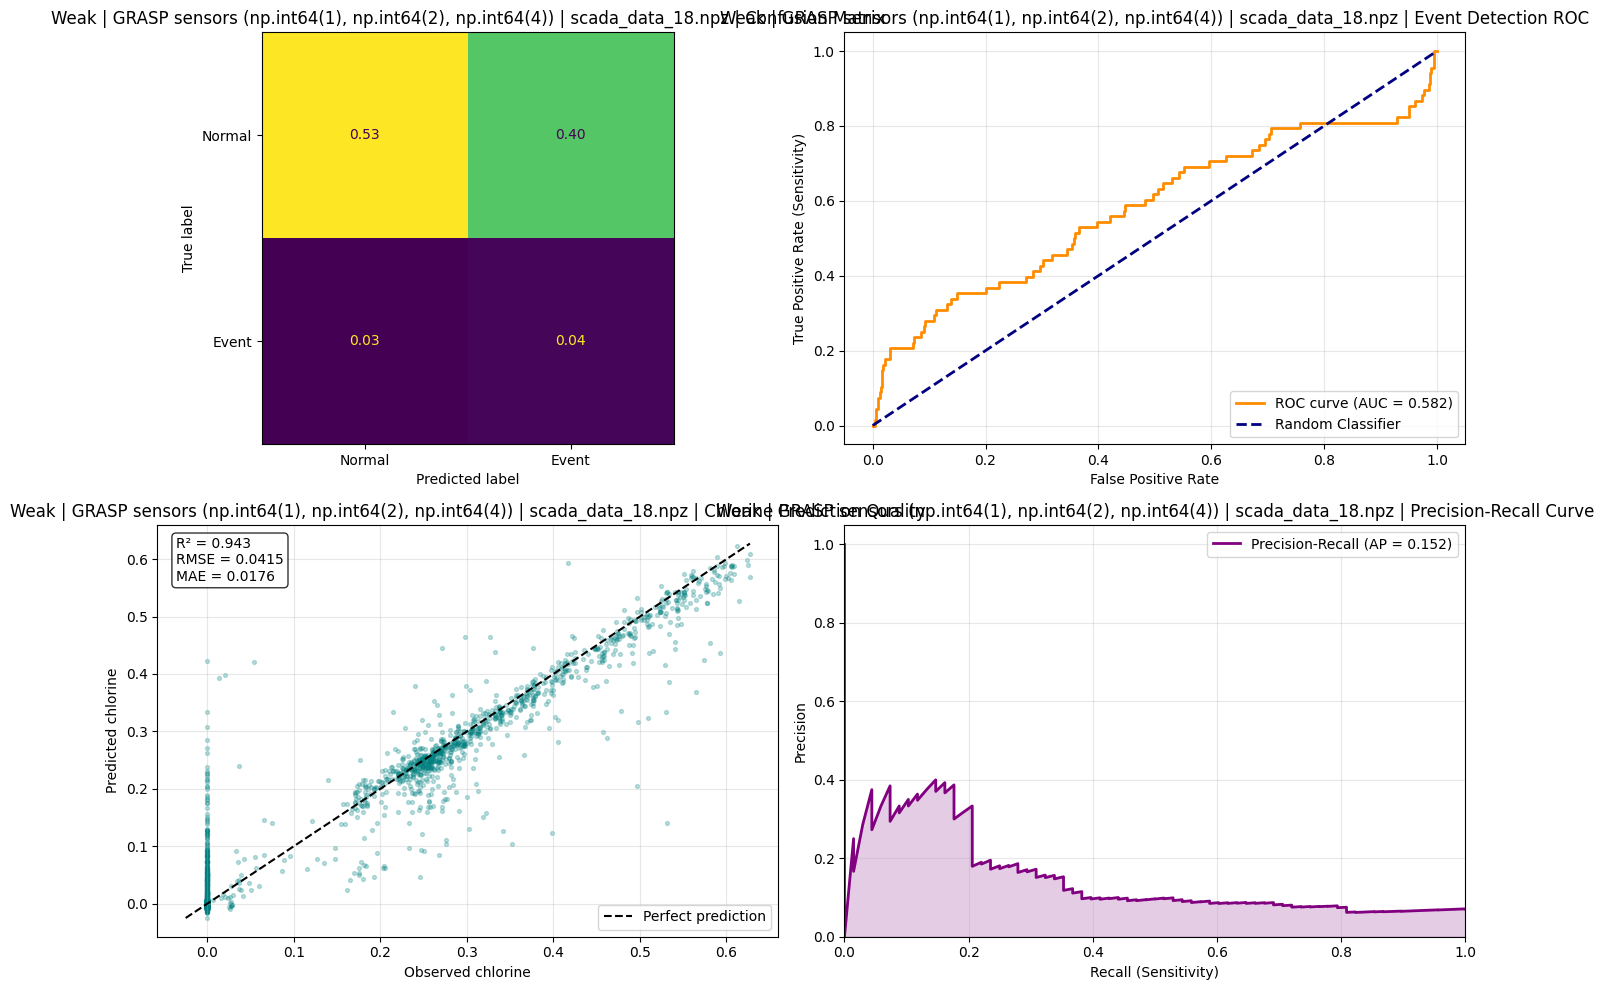

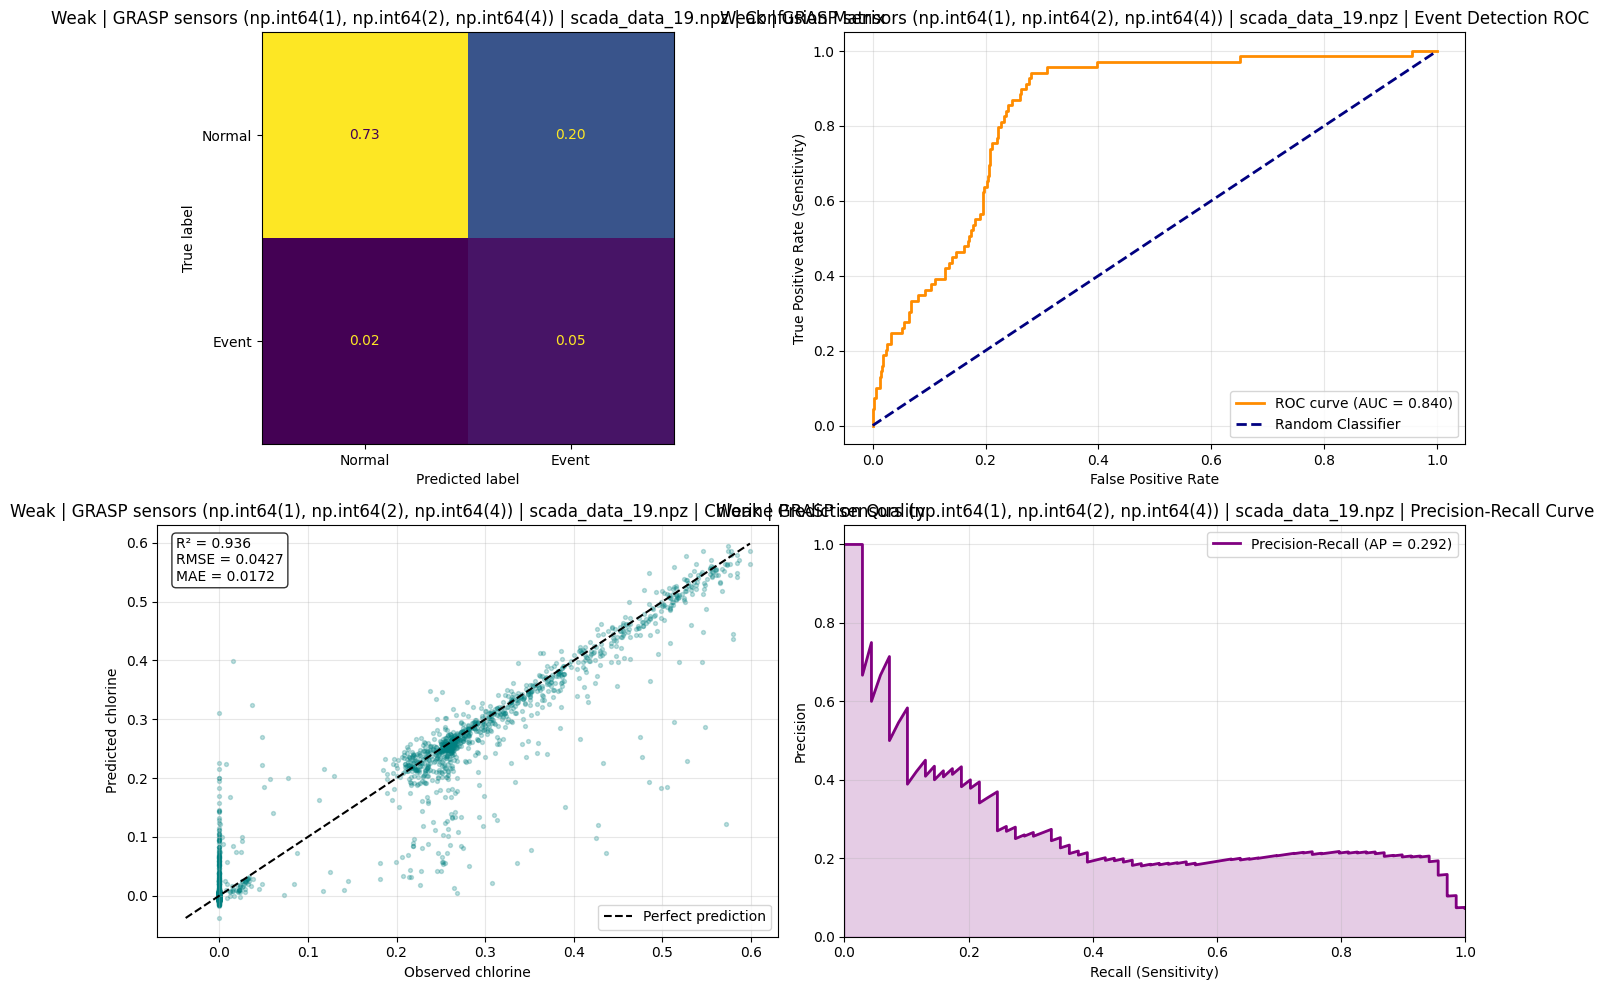

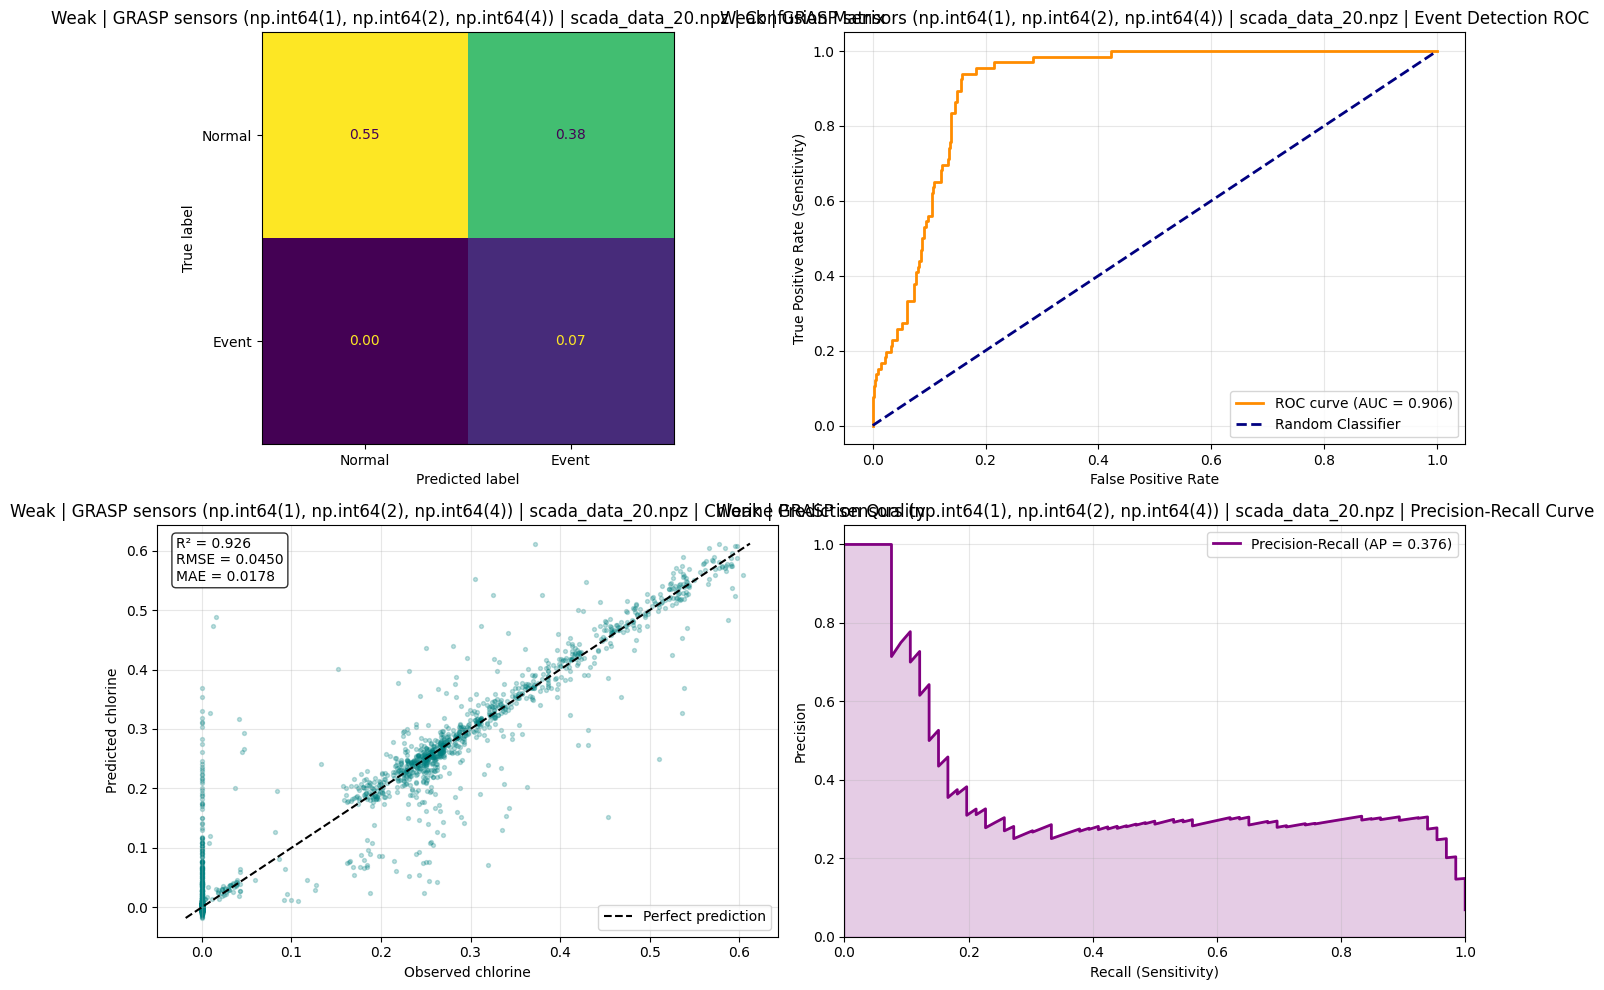

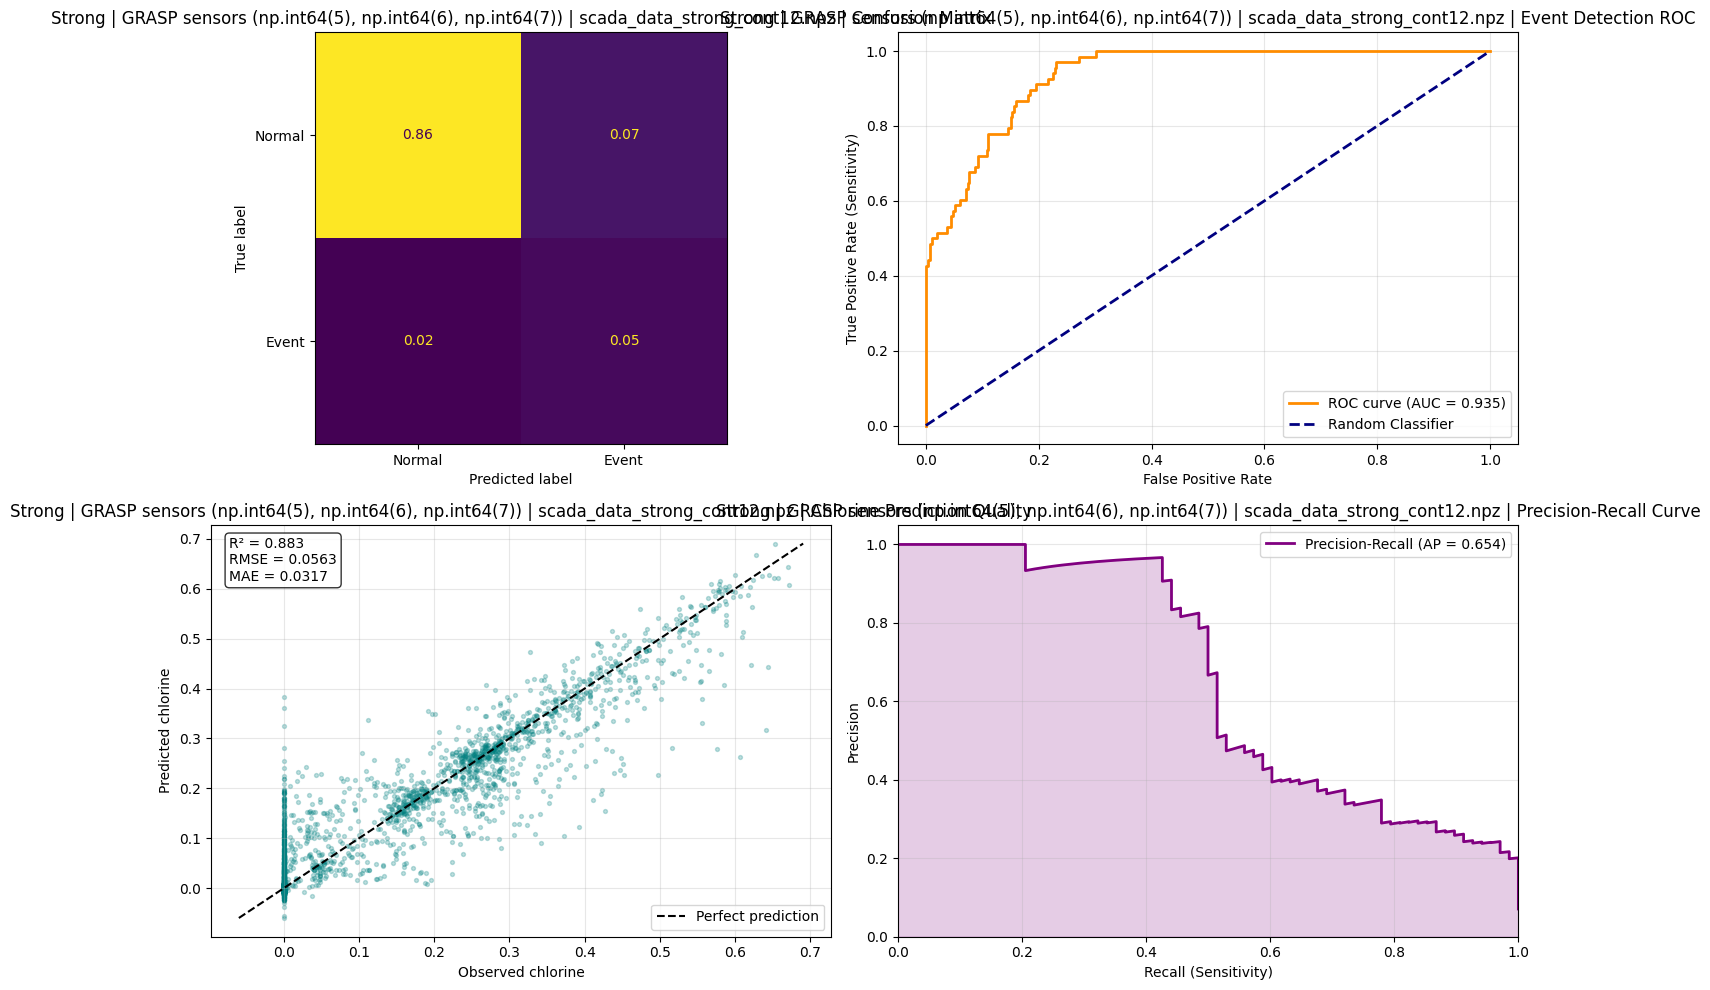

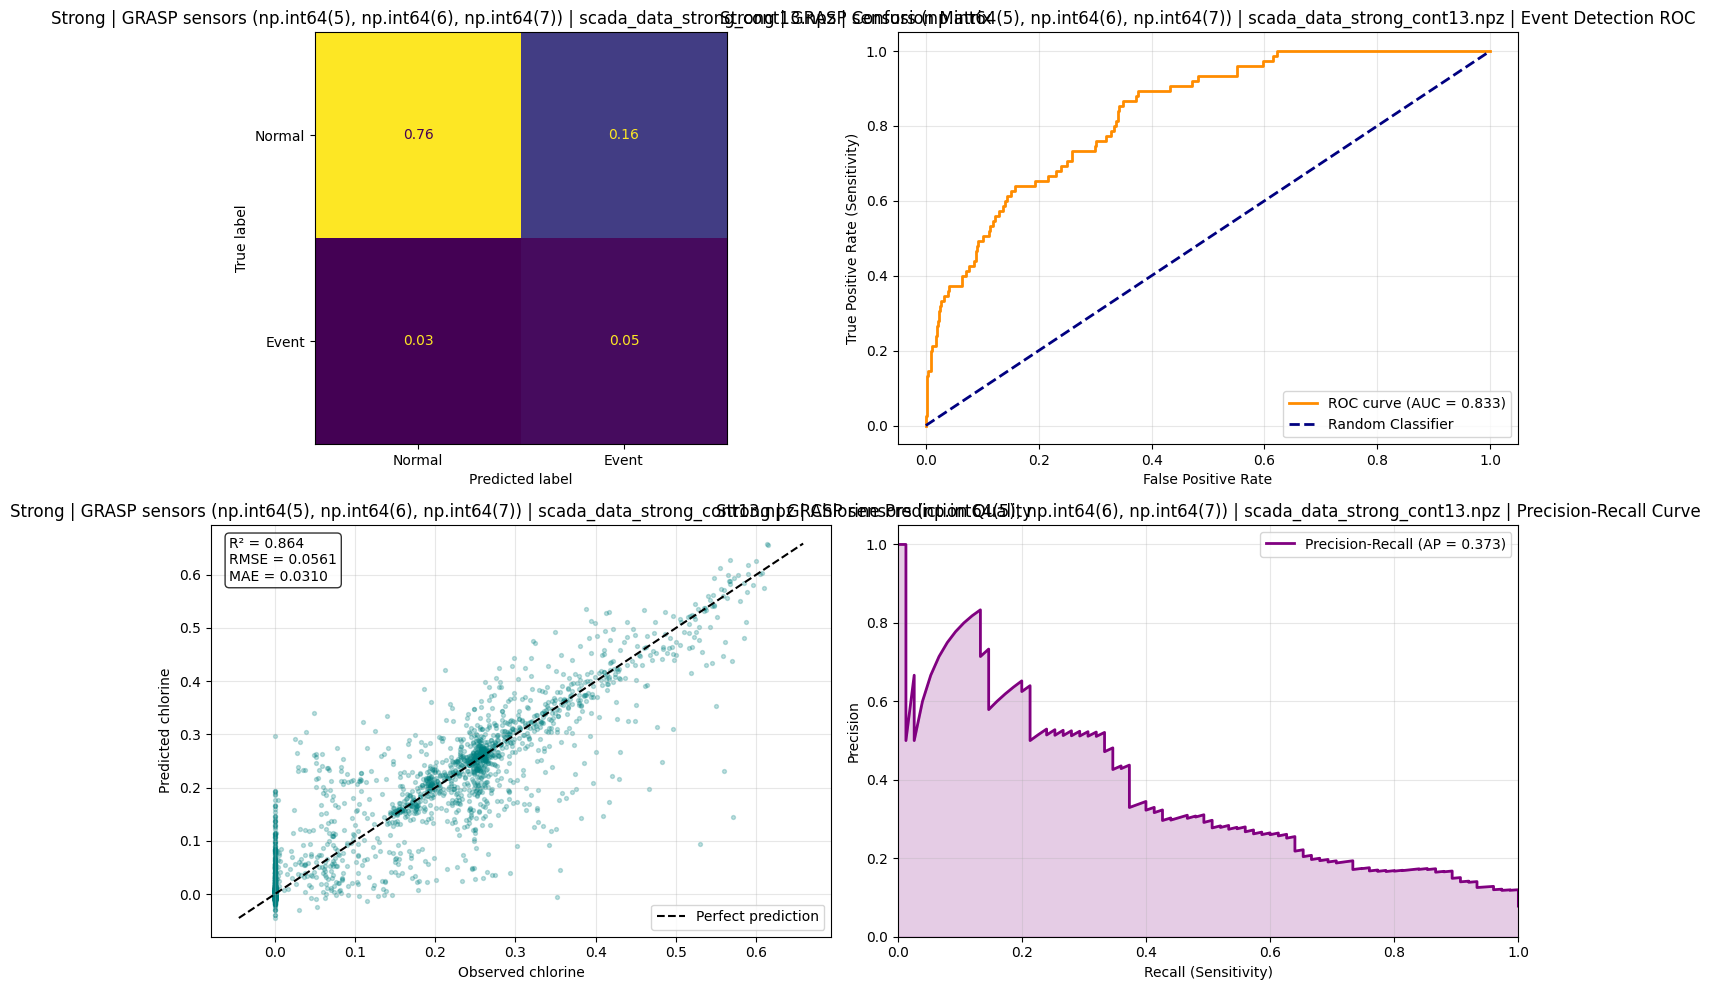

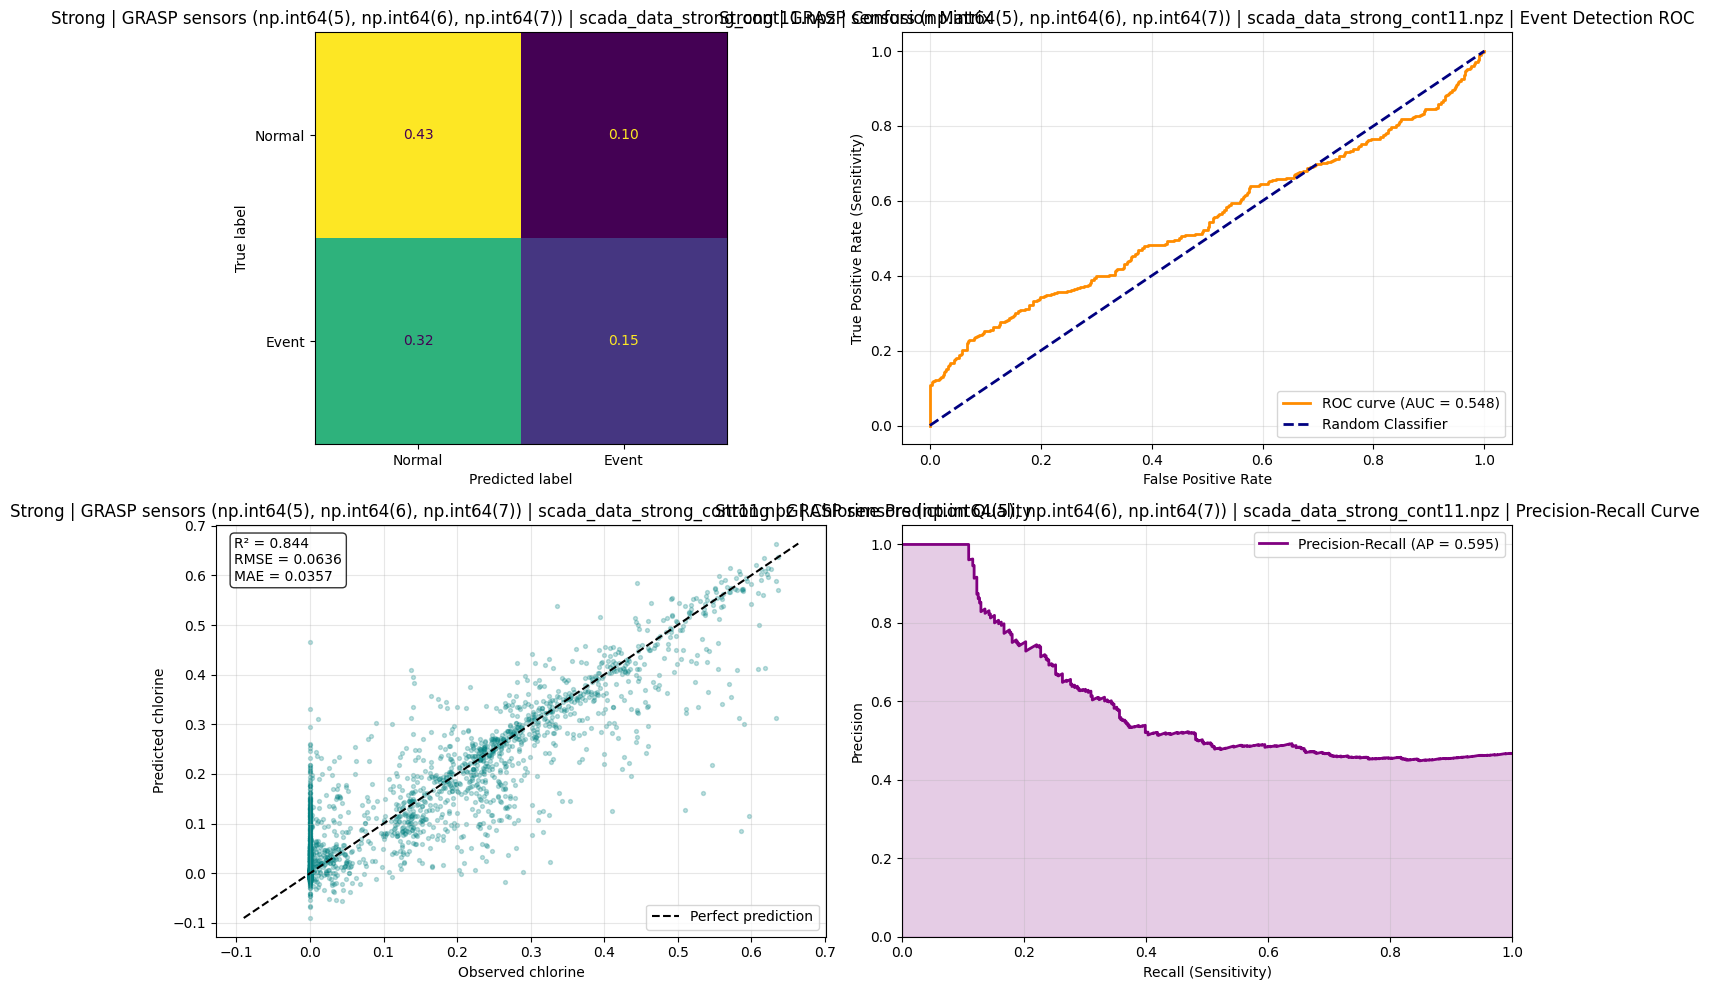

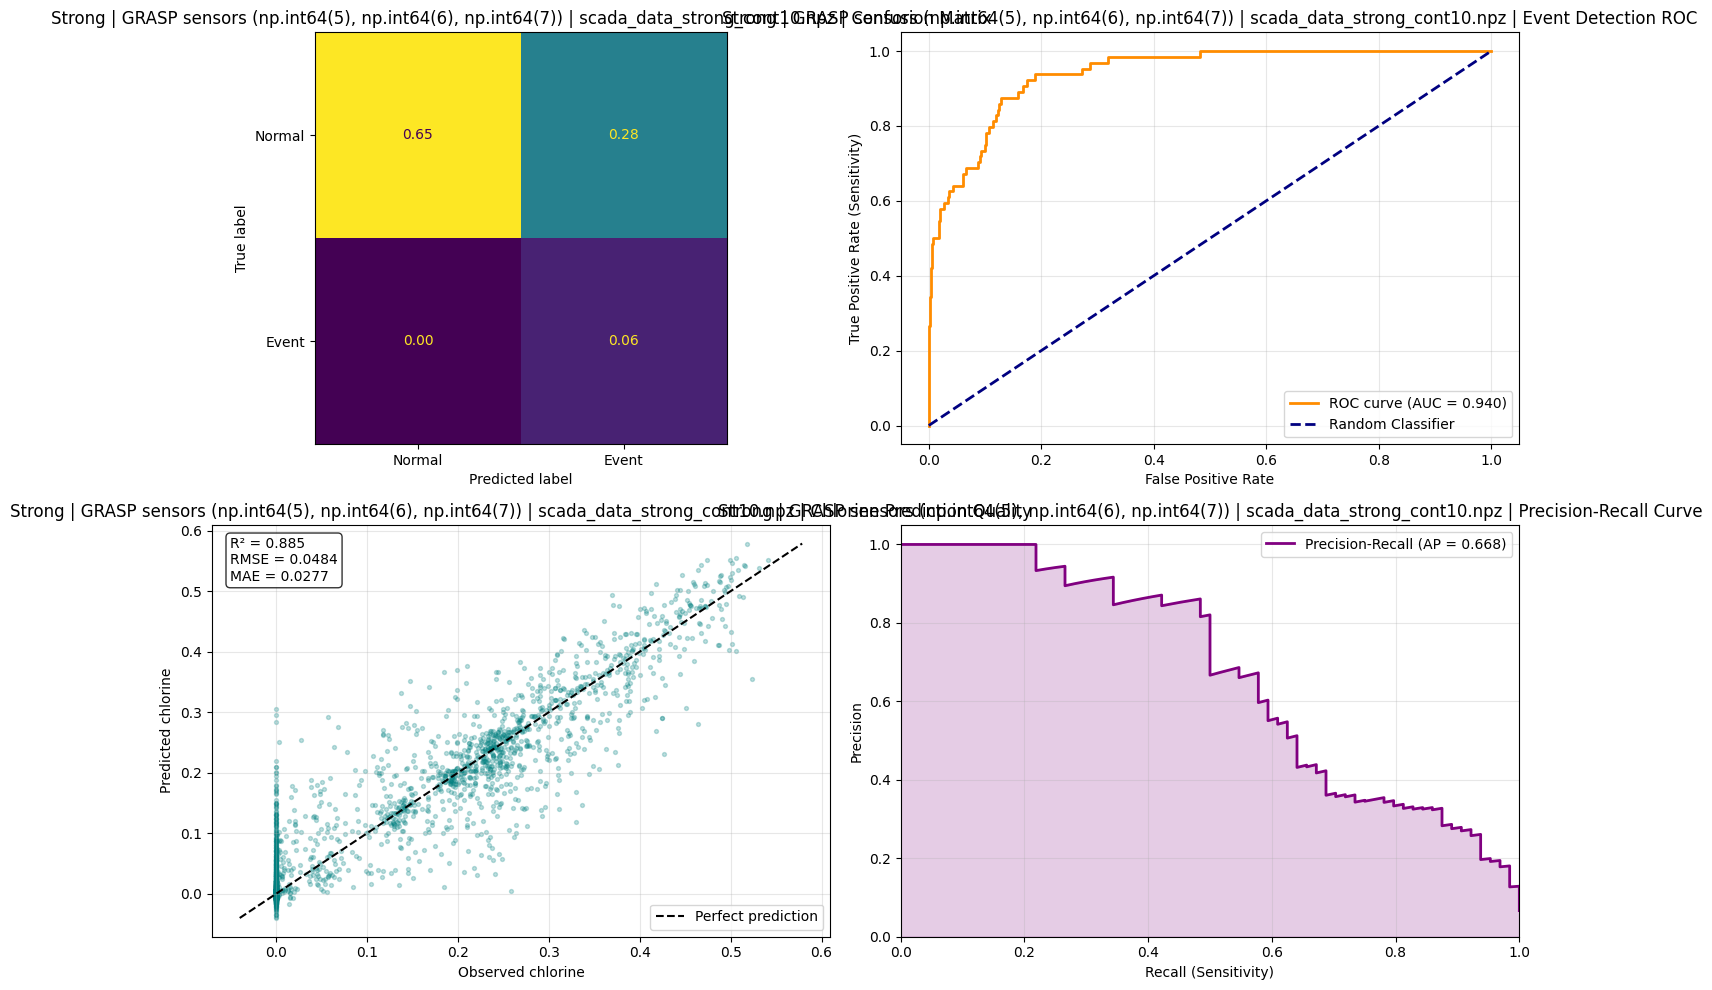

sensor_count               sensor_indices  precision  \
dataset variant                                                                
weak    GRASP selected             3                    (1, 2, 4)   0.125823   
        All sensors                9  (0, 1, 2, 3, 4, 5, 6, 7, 8)   0.175869   
strong  GRASP selected             3                    (5, 6, 7)   0.335946   
        All sensors                9  (0, 1, 2, 3, 4, 5, 6, 7, 8)   0.396505   

                          recall  specificity  balanced_accuracy  accuracy  \
dataset variant                                                              
weak    GRASP selected  0.704797     0.628603           0.666700  0.633975   
        All sensors     0.634686     0.774419           0.704553  0.764568   
strong  GRASP selected  0.457317     0.813990           0.635654  0.753122   
        All sensors     0.449695     0.859159           0.654427  0.789282   

                        f1_score   roc_auc  average_precision  \
dataset variant                                                 
weak    GRASP selected  0.213527  0.732975           0.186648   
        All sensors     0.275420  0.768772           0.194293   
strong  GRASP selected  0.387347  0.688989           0.446858   
        All sensors     0.421429  0.728228           0.492366   

                        false_alarm_rate  detection_latency_seconds  \
dataset variant                                                       
weak    GRASP selected          0.371397                     2250.0   
        All sensors             0.225581                     2250.0   
strong  GRASP selected          0.186010                     7200.0   
        All sensors             0.140841                     5400.0   

                        chlorine_mae  chlorine_rmse  chlorine_r2  
dataset variant                                                   
weak    GRASP selected      0.017260       0.042650     0.936405  
        All sensors         0.022255       0.047137     0.908819  
strong  GRASP selected      0.031539       0.056374     0.868666  
        All sensors         0.022738       0.047576     0.909820

In [10]:
held_out_rows = []
for experiment in experiments:
    detector_variants = {
        "GRASP selected": experiment["selected_detector"],
        "All sensors": experiment["all_sensor_detector"],
    }
    for variant_name, detector in detector_variants.items():
        results = [detector.detect(path) for path in experiment["test_paths"]]
        metrics = aggregate_evaluation_summary(results)
        held_out_rows.append({
            "dataset": experiment["name"],
            "variant": variant_name,
            "sensor_count": len(detector.models),
            "sensor_indices": tuple(detector.chlorine_sensor_indices),
            **metrics,
        })
        if variant_name == "GRASP selected":
            for path, result in zip(experiment["test_paths"], results):
                plot_metrics(
                    result,
                    title_prefix=(
                        f"{experiment['name'].title()} | GRASP sensors "
                        f"{tuple(detector.chlorine_sensor_indices)} | {path.name} | "
                    ),
                    chlorine_indices=list(range(result.actual.shape[1])),
                )

held_out_comparison = pd.DataFrame(held_out_rows).set_index(["dataset", "variant"])
display(held_out_comparison)

held_out_comparison[
    ["balanced_accuracy", "recall", "specificity", "false_alarm_rate",
     "precision", "f1_score", "roc_auc", "average_precision",
     "chlorine_rmse", "chlorine_mae", "chlorine_r2"]
].to_csv(project_root / "results" / "ANN" / "grasp_sensor_weak_strong_comparison.csv")
